====== TASK A: TWO-SAMPLE Z-TEST TOOLKIT ======

--- 1. Assumption Checks ---
Sample Size Check: Control n=50, Treatment n=55
-> Pass: Both sample sizes are >= 30. Central Limit Theorem applies; normality is assumed.
Normality (Shapiro-Wilk p-value): Control p=0.6722, Treatment p=0.3616



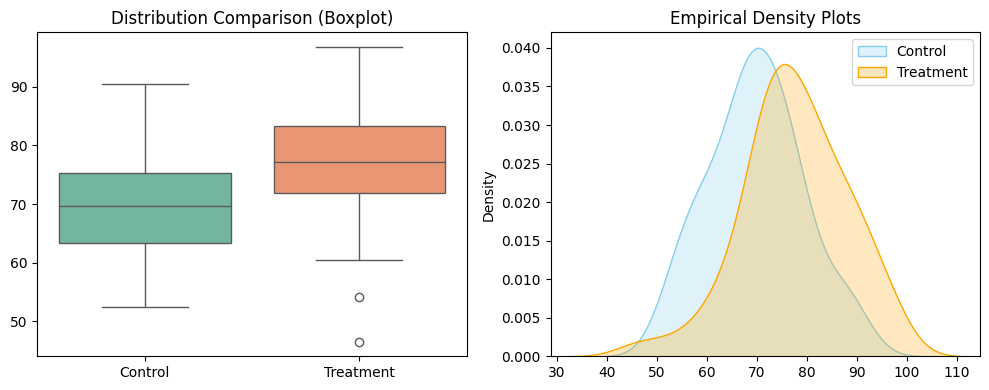


--- 2. Test Results Table ---
                     Metric                              Value
       Null Hypothesis (H0)          μ1 = μ2 (Means are equal)
Alternative Hypothesis (Ha)      μ1 ≠ μ2 (Means are different)
             Sample Size(s)         Control: 50, Treatment: 55
             Sample Mean(s) Control: 69.745, Treatment: 77.508
            Mean Difference                             -7.763
         Test Statistic (Z)                            -4.0360
         Degrees of Freedom               N/A (Z-distribution)
                    p-value                         5.4375e-05
     Significance Level (α)                               0.05
                   Decision                          Reject H0

--------------------------------------------------

--- 3. Conclusion Paragraph ---
Based on the results of the two-sample Z-test, we reject the null hypothesis at a significance level of α = 0.05 (p = 5.4375e-05). There is statistically significant evidence to suggest a dif

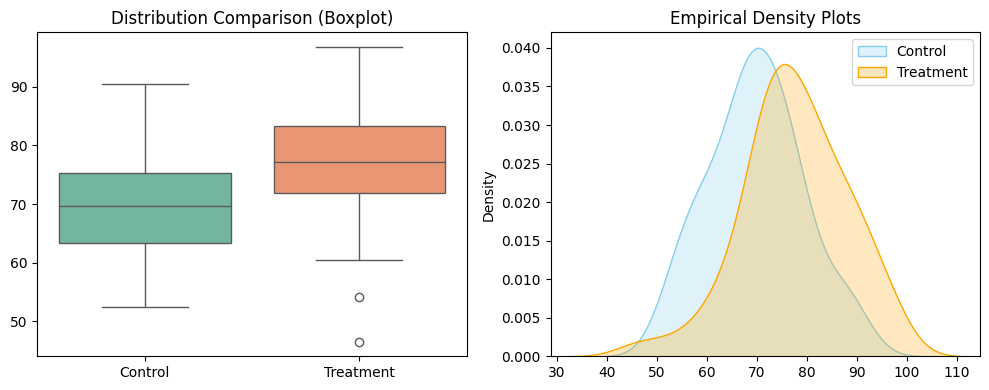


--- 2. Test Results Table ---
                     Metric                              Value
       Null Hypothesis (H0)          μ1 = μ2 (Means are equal)
Alternative Hypothesis (Ha)      μ1 ≠ μ2 (Means are different)
             Sample Size(s)         Control: 50, Treatment: 55
             Sample Mean(s) Control: 69.745, Treatment: 77.508
            Mean Difference                             -7.763
         Test Statistic (Z)                            -4.0360
         Degrees of Freedom               N/A (Z-distribution)
                    p-value                         5.4375e-05
     Significance Level (α)                               0.05
                   Decision                          Reject H0

--------------------------------------------------

--- 3. Conclusion Paragraph ---
Based on the results of the two-sample Z-test, we reject the null hypothesis at a significance level of α = 0.05 (p = 5.4375e-05). There is statistically significant evidence to suggest a dif

In [ ]:

# HOME ASSIGNMENT-7
# TOOLS AND METHODS OF DATA ANALYSIS - TASK A: TWO-SAMPLE Z-TEST TOOLKIT
# KARTHIK REDDY CHILKURI
# 100008159

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

def z_test_toolkit(group1, group2, label1="Group 1", label2="Group 2", alpha=0.05):
    print("====== TASK A: TWO-SAMPLE Z-TEST TOOLKIT ======\n")
    
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    mean_diff = mean1 - mean2
    
    # 1. Assumption Checks
    print("--- 1. Assumption Checks ---")
    print(f"Sample Size Check: {label1} n={n1}, {label2} n={n2}")
    if n1 >= 30 and n2 >= 30:
        print("-> Pass: Both sample sizes are >= 30. Central Limit Theorem applies; normality is assumed.")
    else:
        print("-> Warning: Sample size is small. Check for severe skewness or outliers.")
        
    # Normality Visual Check (Shapiro-Wilk for reference)
    _, p_norm1 = stats.shapiro(group1)
    _, p_norm2 = stats.shapiro(group2)
    print(f"Normality (Shapiro-Wilk p-value): {label1} p={p_norm1:.4f}, {label2} p={p_norm2:.4f}\n")

    # 2. Data Visualization
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.boxplot(data=[group1, group2], palette="Set2")
    plt.xticks([0, 1], [label1, label2])
    plt.title("Distribution Comparison (Boxplot)")
    
    plt.subplot(1, 2, 2)
    sns.kdeplot(group1, label=label1, fill=True, color="skyblue")
    sns.kdeplot(group2, label=label2, fill=True, color="orange")
    plt.title("Empirical Density Plots")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3. Perform Z-test
    # Z = (mean1 - mean2) / sqrt(var1/n1 + var2/n2)
    z_stat = mean_diff / np.sqrt((var1 / n1) + (var2 / n2))
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat))) # Two-tailed
    
    decision = "Reject H0" if p_value < alpha else "Fail to Reject H0"

    # Summary Table
    results_data = {
        "Metric": [
            "Null Hypothesis (H0)", "Alternative Hypothesis (Ha)", 
            "Sample Size(s)", "Sample Mean(s)", "Mean Difference", 
            "Test Statistic (Z)", "Degrees of Freedom", "p-value", "Significance Level (α)", "Decision"
        ],
        "Value": [
            "μ1 = μ2 (Means are equal)", "μ1 ≠ μ2 (Means are different)",
            f"{label1}: {n1}, {label2}: {n2}", f"{label1}: {mean1:.3f}, {label2}: {mean2:.3f}", f"{mean_diff:.3f}",
            f"{z_stat:.4f}", "N/A (Z-distribution)", f"{p_value:.4e}", f"{alpha}", decision
        ]
    }
    df_results = pd.DataFrame(results_data)
    
    print("\n--- 2. Test Results Table ---")
    print(df_results.to_string(index=False))
    print("\n" + "-"*50)
    
    # 4. Automatically Generated Conclusion Paragraph
    print("\n--- 3. Conclusion Paragraph ---")
    if p_value < alpha:
        conclusion = (
            f"Based on the results of the two-sample Z-test, we reject the null hypothesis at a significance level of α = {alpha} "
            f"(p = {p_value:.4e}). There is statistically significant evidence to suggest a difference between the true population "
            f"means of {label1} and {label2}. Specifically, the sample mean of {label1} ({mean1:.3f}) differs from {label2} ({mean2:.3f}) "
            f"by an observed mean difference of {mean_diff:.3f}."
        )
    else:
        conclusion = (
            f"Based on the results of the two-sample Z-test, we fail to reject the null hypothesis at a significance level of α = {alpha} "
            f"(p = {p_value:.4f}). There is insufficient evidence to suggest a statistically significant difference between the "
            f"true population means of {label1} and {label2}. Any observed difference between the sample means ({mean1:.3f} vs. {mean2:.3f}) "
            f"can likely be attributed to random sampling error."
        )
    print(conclusion)
    print("\n" + "="*50)

# --- Example Usage for Testing Task A ---
np.random.seed(42)
group_A = np.random.normal(loc=72, scale=10, size=50) # e.g., Control Group
group_B = np.random.normal(loc=78, scale=12, size=55) # e.g., Treatment Group
z_test_toolkit(group_A, group_B, "Control", "Treatment")
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

def z_test_toolkit(group1, group2, label1="Group 1", label2="Group 2", alpha=0.05):
    print("====== TASK A: TWO-SAMPLE Z-TEST TOOLKIT ======\n")
    
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    mean_diff = mean1 - mean2
    
    # 1. Assumption Checks
    print("--- 1. Assumption Checks ---")
    print(f"Sample Size Check: {label1} n={n1}, {label2} n={n2}")
    if n1 >= 30 and n2 >= 30:
        print("-> Pass: Both sample sizes are >= 30. Central Limit Theorem applies; normality is assumed.")
    else:
        print("-> Warning: Sample size is small. Check for severe skewness or outliers.")
        
    # Normality Visual Check (Shapiro-Wilk for reference)
    _, p_norm1 = stats.shapiro(group1)
    _, p_norm2 = stats.shapiro(group2)
    print(f"Normality (Shapiro-Wilk p-value): {label1} p={p_norm1:.4f}, {label2} p={p_norm2:.4f}\n")

    # 2. Data Visualization
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.boxplot(data=[group1, group2], palette="Set2")
    plt.xticks([0, 1], [label1, label2])
    plt.title("Distribution Comparison (Boxplot)")
    
    plt.subplot(1, 2, 2)
    sns.kdeplot(group1, label=label1, fill=True, color="skyblue")
    sns.kdeplot(group2, label=label2, fill=True, color="orange")
    plt.title("Empirical Density Plots")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3. Perform Z-test
    # Z = (mean1 - mean2) / sqrt(var1/n1 + var2/n2)
    z_stat = mean_diff / np.sqrt((var1 / n1) + (var2 / n2))
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat))) # Two-tailed
    
    decision = "Reject H0" if p_value < alpha else "Fail to Reject H0"

    # Summary Table
    results_data = {
        "Metric": [
            "Null Hypothesis (H0)", "Alternative Hypothesis (Ha)", 
            "Sample Size(s)", "Sample Mean(s)", "Mean Difference", 
            "Test Statistic (Z)", "Degrees of Freedom", "p-value", "Significance Level (α)", "Decision"
        ],
        "Value": [
            "μ1 = μ2 (Means are equal)", "μ1 ≠ μ2 (Means are different)",
            f"{label1}: {n1}, {label2}: {n2}", f"{label1}: {mean1:.3f}, {label2}: {mean2:.3f}", f"{mean_diff:.3f}",
            f"{z_stat:.4f}", "N/A (Z-distribution)", f"{p_value:.4e}", f"{alpha}", decision
        ]
    }
    df_results = pd.DataFrame(results_data)
    
    print("\n--- 2. Test Results Table ---")
    print(df_results.to_string(index=False))
    print("\n" + "-"*50)
    
    # 4. Automatically Generated Conclusion Paragraph
    print("\n--- 3. Conclusion Paragraph ---")
    if p_value < alpha:
        conclusion = (
            f"Based on the results of the two-sample Z-test, we reject the null hypothesis at a significance level of α = {alpha} "
            f"(p = {p_value:.4e}). There is statistically significant evidence to suggest a difference between the true population "
            f"means of {label1} and {label2}. Specifically, the sample mean of {label1} ({mean1:.3f}) differs from {label2} ({mean2:.3f}) "
            f"by an observed mean difference of {mean_diff:.3f}."
        )
    else:
        conclusion = (
            f"Based on the results of the two-sample Z-test, we fail to reject the null hypothesis at a significance level of α = {alpha} "
            f"(p = {p_value:.4f}). There is insufficient evidence to suggest a statistically significant difference between the "
            f"true population means of {label1} and {label2}. Any observed difference between the sample means ({mean1:.3f} vs. {mean2:.3f}) "
            f"can likely be attributed to random sampling error."
        )
    print(conclusion)
    print("\n" + "="*50)

# --- Example Usage for Testing Task A ---
np.random.seed(42)
group_A = np.random.normal(loc=72, scale=10, size=50) # e.g., Control Group
group_B = np.random.normal(loc=78, scale=12, size=55) # e.g., Treatment Group
z_test_toolkit(group_A, group_B, "Control", "Treatment")